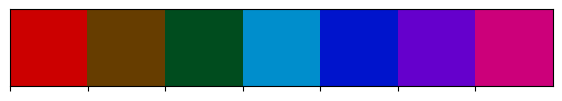

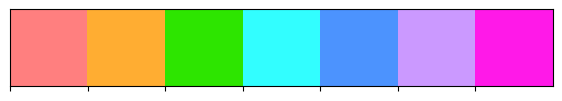

In [34]:
import torch
import os
import sys
import numpy as np
import scipy
import gymnasium as gym
import random
import matplotlib.pylab as plt
import time
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.wrappers.env_wrappers import WallObs, WindowViewObs, ObsToImage, MultiChannel
from src.wrappers.monitor_wrappers import BinaryMonitor, RoomMonitor
from src.policy_analysis import discount_episode_reward, sum_ep_timesteps, set_blind_colors
light_colors, dark_colors = set_blind_colors()

In [9]:
device = "mps:0"
grid_size = [10, 10]
eps_decay = 0.0001
n_mdp_actions = 6
window_size = 11
dryness = 0.05
gamma = 0.99
q_lr = 0.0001
r_lr = 0.0001
n_rows, n_colums = grid_size

n_checks = 23
n_ep = 10
n_seeds = 10

main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/room/window_{}/eps_decay_{}/q_lr_{}/reward_lr_{}".format(
    n_rows, n_colums, dryness, window_size, eps_decay, q_lr, r_lr)

reward_models, q_models = [], []
for seed in range(n_seeds):
    for check in range(n_checks):
        q_models.append(torch.load(main_dir + "/checkpoints_{}/q_network_{}".format(check, seed), map_location=torch.device(device), weights_only=False))
        reward_models.append(torch.load(main_dir + "/checkpoints_{}/reward_model_{}".format(check, seed), map_location=torch.device(device), weights_only=False))

def confidence_interval(data, confidence=0.95):
    conf = scipy.stats.sem(data) * scipy.stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return conf

def confidence_interval_2d(data: np.ndarray, confidence: float=0.95):
    confds = []
    for j in range(data.shape[1]):
        k = confidence_interval(data[:, j])
        confds.append(k)
    return np.array(confds)


def bootstrap_ci_2d(data, stat_function=np.mean, n_bootstrap=1000, ci=95):
    """
    Computes bootstrap confidence intervals for each row of a 2D array (axis=1), vectorized.

    Parameters:
        data (array-like): 2D sample data of shape (n_rows, n_samples).
        stat_function (function): Function to compute the statistic along axis=1 (default: np.mean).
                                  Must support axis argument.
        n_bootstrap (int): Number of bootstrap resamples (default: 1000).
        ci (float): Confidence level (default: 95 for a 95% confidence interval).

    Returns:
        np.ndarray: Array of shape (n_rows, 2), where each row is [lower_bound, upper_bound].
    """
    data = np.asarray(data)
    n_rows, n_samples = data.shape

    # Generate all bootstrap sample indices at once
    resample_idx = np.random.randint(0, n_samples, size=(n_bootstrap, n_samples))

    # Gather samples: shape (n_rows, n_bootstrap, n_samples)
    boot_samples = data[:, resample_idx]

    # Compute statistics along the sample axis
    boot_stats = stat_function(boot_samples, axis=1)  # shape (n_rows, n_bootstrap)

    # Confidence interval percentiles
    lower_percentile = (100 - ci) / 2
    upper_percentile = 100 - lower_percentile

    lower_bounds = np.percentile(boot_stats, lower_percentile, axis=0)
    upper_bounds = np.percentile(boot_stats, upper_percentile, axis=0)

    return np.column_stack((lower_bounds, upper_bounds))

In [10]:
obs_mon = np.squeeze(np.load(main_dir + "/monitor_obs.npy"))
obs_env = np.squeeze(np.load(main_dir + "/env_obs.npy"))

In [42]:
obs_env.shape

(10, 23, 6, 11, 11)

In [38]:
obs_env_sample = torch.tensor(obs_env[:, 2], dtype=torch.float32, device=device)#.unsqueeze(0)
obs_mon_sample = torch.tensor(obs_mon[:, 2], dtype=torch.float32, device=device)#.unsqueeze(0)

In [39]:
reward_models[0], q_models[0], obs_env_sample.shape

(Sequential(
   (0): Linear(in_features=6, out_features=128, bias=True)
   (1): ReLU()
   (2): Linear(in_features=128, out_features=64, bias=True)
   (3): ReLU()
   (4): Linear(in_features=64, out_features=6, bias=True)
 ),
 Sequential(
   (0): Conv2d(6, 32, kernel_size=(5, 5), stride=(1, 1))
   (1): ReLU()
   (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
   (3): ReLU()
   (4): Flatten(start_dim=1, end_dim=-1)
   (5): Linear(in_features=1601, out_features=512, bias=True)
   (6): ReLU()
   (7): Linear(in_features=512, out_features=6, bias=True)
 ),
 torch.Size([10, 6, 11, 11]))

In [40]:
obs_env_sample[:, :, 5, 5].shape

torch.Size([10, 6])

In [41]:
reward_models[0](obs_env_sample[:, :, 5, 5]).detach()

tensor([[-0.1267, -0.1023,  0.0213, -0.1257,  0.0733,  0.1144],
        [-0.1607, -0.1287,  0.0181, -0.1043,  0.1154,  0.1035],
        [-0.1267, -0.1023,  0.0213, -0.1257,  0.0733,  0.1144],
        [-0.0949, -0.0765,  0.0689, -0.0137, -0.0641, -0.0242],
        [-0.1267, -0.1023,  0.0213, -0.1257,  0.0733,  0.1144],
        [-0.1607, -0.1287,  0.0181, -0.1043,  0.1154,  0.1035],
        [-0.1267, -0.1023,  0.0213, -0.1257,  0.0733,  0.1144],
        [-0.1267, -0.1023,  0.0213, -0.1257,  0.0733,  0.1144],
        [-0.1267, -0.1023,  0.0213, -0.1257,  0.0733,  0.1144],
        [-0.1607, -0.1287,  0.0181, -0.1043,  0.1154,  0.1035]],
       device='mps:0')

In [7]:
def percent_active_parameters(model, threshold=1e-3, device="cpu"):
    """
    Loads a PyTorch model and computes the number and percentage of active
    parameters (|param| > threshold) for each layer and the whole model.

    Returns:
        layer_stats (dict): 
            { layer_name: 
                { "percent_active": float,
                  "active": int,
                  "total": int }
            }
        model_active (int): total active parameters across the model
        model_total (int): total parameters
        model_percent_active (float): percentage of active parameters overall
    """
    # Load model
    model.eval()

    layer_stats = {}
    model_active = 0
    model_total = 0

    for name, param in model.named_parameters():
        if param.requires_grad:
            p = param.detach().abs()
            active = (p > threshold).sum().item()
            total = p.numel()

            layer_stats[name] = {
                "percent_active": 100 * active / total,
                "active": active,
                "total": total
            }

            model_active += active
            model_total += total

    model_percent_active = 100 * model_active / model_total

    return layer_stats, model_active, model_total, model_percent_active

In [19]:
_, _, _, model_pct = percent_active_parameters(models[0], threshold=1e-3)
print(f"Total active params: {model_active}/{model_total} ({model_pct:.2f}%)")

layer_stats, model_active, model_total, model_pct = percent_active_parameters(models[-1], threshold=1e-3)
print(f"Total active params: {model_active}/{model_total} ({model_pct:.2f}%)")

Total active params: 815784/849196 (96.07%)
Total active params: 828653/849196 (97.58%)


In [54]:
reward_model_percent, q_model_percent = [], []
for check in range(n_checks):
    _, _, _, reward_model_pct = percent_active_parameters(reward_models[check], threshold=1e-4)
    _, _, _, q_model_pct = percent_active_parameters(q_models[check], threshold=1e-4)
    reward_model_percent.append(reward_model_pct)
    q_model_percent.append(q_model_pct)

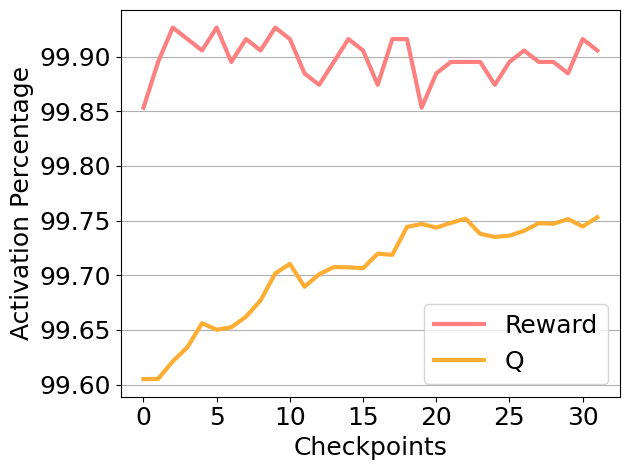

In [55]:
plt.plot(np.arange(n_checks), reward_model_percent, lw=3, color=light_colors[0], label="Reward")
plt.plot(np.arange(n_checks), q_model_percent, lw=3, color=light_colors[1], label="Q")
plt.xlabel("Checkpoints", fontsize=18) #($10^{6}$)
plt.ylabel("Activation Percentage", fontsize=18)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.grid(axis="y")
plt.legend(fontsize=18)
plt.tight_layout()

In [51]:
n_seeds = 10
n_checks = 23
reward_active = np.zeros((n_seeds, n_checks))
q_active = np.zeros((n_seeds, n_checks))
for seed in range(n_seeds):
    for check in range(n_checks):
        q_model = torch.load(main_dir + "/checkpoints_{}/q_network_{}".format(check, seed), map_location=torch.device(device), weights_only=False)
        reward_model = torch.load(main_dir + "/checkpoints_{}/reward_model_{}".format(check, seed), map_location=torch.device(device), weights_only=False)

        # reward_active[seed, check] = compute_dormant_units_proportion(reward_model, obs_env_sample, 0.01, obs_mon_sample)
        q_active[seed, check] = compute_dormant_units_proportion(q_model, obs_env_sample, 0.001, obs_mon_sample)
        # q_active[seed, check] = compute_dormant_units_proportion(q_model, obs_env_sample, 0.01)

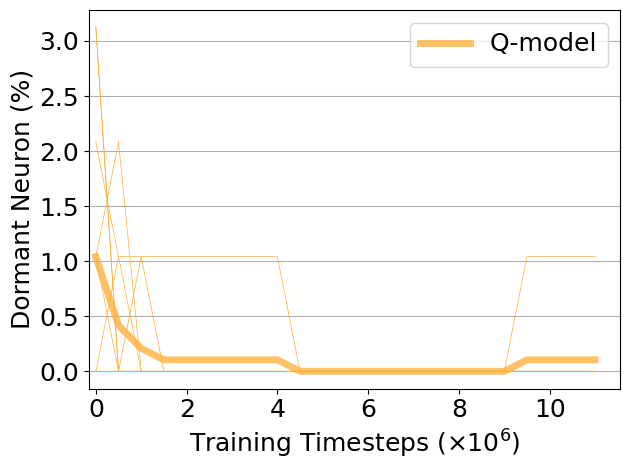

In [52]:
x_axis = np.arange(0, int(n_checks * 5e5), int(5e5)) / 1e6
# plt.plot(np.arange(n_checks), np.mean(reward_active, 0), lw=3, color=light_colors[0], label="Reward")
plt.plot(x_axis, np.mean(q_active, 0), lw=5, color=light_colors[1], alpha=0.75, label="Q-model")
ci_q_model = bootstrap_ci_2d(q_active, ci=90)
# plt.fill_between(x_axis, ci_q_model[:, 0], ci_q_model[:, 1], color=light_colors[1], alpha=0.3)

for seed in range(n_seeds):
    plt.plot(x_axis, q_active[seed], lw=0.5, color=light_colors[1])
    
plt.xlabel(r"Training Timesteps ($\times 10^6$)", fontsize=18) #($10^{6}$)
plt.ylabel("Dormant Neuron (%)", fontsize=18)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.grid(axis="y")
plt.xlim(-0.15,)
plt.legend(fontsize=18)
plt.tight_layout()

In [68]:
q_models[0], reward_models[0]

(Sequential(
   (0): Conv2d(6, 32, kernel_size=(5, 5), stride=(1, 1))
   (1): ReLU()
   (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
   (3): ReLU()
   (4): Flatten(start_dim=1, end_dim=-1)
   (5): Linear(in_features=1601, out_features=512, bias=True)
   (6): ReLU()
   (7): Linear(in_features=512, out_features=6, bias=True)
 ),
 Sequential(
   (0): Linear(in_features=6, out_features=128, bias=True)
   (1): ReLU()
   (2): Linear(in_features=128, out_features=64, bias=True)
   (3): ReLU()
   (4): Linear(in_features=64, out_features=6, bias=True)
 ))

In [4]:
n_seeds = 10
n_checks = 32
reward_active = np.zeros((n_seeds, n_checks))
q_active = np.zeros((n_seeds, n_checks))
for seed in range(n_seeds):
    for check in range(n_checks):
        q_model = torch.load(main_dir + "/checkpoints_{}/q_network_{}".format(check, seed), map_location=torch.device(device), weights_only=False)
        reward_model = torch.load(main_dir + "/checkpoints_{}/reward_model_{}".format(check, seed), map_location=torch.device(device), weights_only=False)
        q_values = q_model(obs_sample).detach().cpu()
        reward_values = reward_model(obs_sample).detach().cpu()
        with torch.no_grad():
            

        _, _, _, reward_model_pct = percent_active_parameters(reward_model, threshold=1e-4)
        _, _, _, q_model_pct = percent_active_parameters(q_model, threshold=1e-4)
        reward_active[seed, check] = reward_model_pct
        q_active[seed, check] = q_model_pct

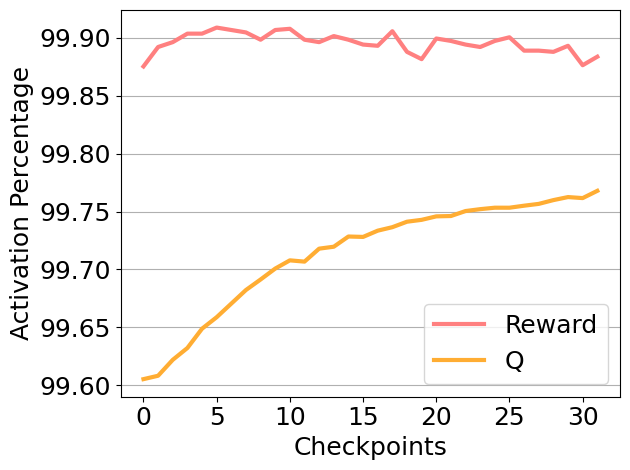

In [5]:
plt.plot(np.arange(n_checks), np.mean(reward_active, 0), lw=3, color=light_colors[0], label="Reward")
plt.plot(np.arange(n_checks), np.mean(q_active, 0), lw=3, color=light_colors[1], label="Q")
plt.xlabel("Checkpoints", fontsize=18) #($10^{6}$)
plt.ylabel("Activation Percentage", fontsize=18)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.grid(axis="y")
plt.legend(fontsize=18)
plt.tight_layout()

In [53]:
def get_features(model: torch.nn.Module, obs_env: torch.Tensor, obs_mon: torch.Tensor = None):
    """
    Extract post-activation features from each layer of a PyTorch model.

    Args:
        model: nn.Sequential
        obs_env: input tensor — single (C, H, W) or batch (N, C, H, W)
        obs_mon: optional monitor observation — scalar or (N,)
    Returns:
        List of activation tensors, one per ReLU layer
    """
    if obs_env.dim() == 3:
        obs_env = obs_env.unsqueeze(0)

    features = []
    hooks = []

    def register_hook(module):
        def hook(_, __, output):
            features.append(output.detach())
        return hook

    for _, module in model.named_modules():
        if isinstance(module, torch.nn.ReLU):
            hooks.append(module.register_forward_hook(register_hook(module)))

    with torch.no_grad():
        if obs_mon is not None:
            if obs_mon.dim() == 0:
                obs_mon = obs_mon.unsqueeze(0)
            model[5:](torch.concat((model[:5](obs_env), obs_mon.view(-1, 1)), 1))
        else:
            model(obs_env)

    for h in hooks:
        h.remove()

    return features

In [ ]:
def _true_reward_from_obs(center_pixel: torch.Tensor) -> torch.Tensor:
    """
    Derives the true reward for all 6 actions from the center pixel of the
    MultiChannel observation. The 6 channels at center are:
      [0] agent, [1] R, [2] G, [3] B, [4] dryness, [5] wall

    Reward rules (plant watering env):
      actions 0-3 (move), 5 (nothing) → 0.0
      action 4 (water):
        dry plant (dryness > 0)       → +1.0
        watered plant (dryness == 0)  → -1.0
        no plant (RGB all zero)       → -0.2

    Args:
        center_pixel: (N, 6) center pixel features
    Returns:
        (N, 6) true rewards for each action
    """
    N = center_pixel.shape[0]
    rewards = torch.zeros(N, 6, device=center_pixel.device)

    has_plant = (center_pixel[:, 1:4].abs().sum(dim=1) > 1e-6)
    is_dry = (center_pixel[:, 4] > 1e-6)

    water_reward = torch.where(
        has_plant & is_dry,
        torch.tensor(1.0, device=center_pixel.device),
        torch.where(
            has_plant & ~is_dry,
            torch.tensor(-1.0, device=center_pixel.device),
            torch.tensor(-0.2, device=center_pixel.device),
        ),
    )
    rewards[:, 4] = water_reward
    return rewards


def compute_overgeneralization(
    reward_model: torch.nn.Module,
    obs_states: torch.Tensor,
    unobs_states: torch.Tensor,
    flatten: bool = True,
) -> np.ndarray:
    """
    Measures overgeneralization as the ratio of reward model MSE on
    unobservable states to MSE on observable states, using the
    half-room reward function to derive true rewards.

    Evaluates all 6 actions: [0, 1, 2, 3, 4, 5].

    Unobservable MSE: E[(R_hat(s,a) - r_true)^2 | unobservable]
    Observable MSE:   E[(R_hat(s,a) - r_true)^2 | observable]

    Args:
        reward_model: the reward prediction network
        obs_states: (N_obs, C, H, W) observable environment observations
        unobs_states: (N_unobs, C, H, W) unobservable environment observations
        flatten: if True, extract center pixel before feeding to model

    Returns:
        np.ndarray of shape (3,): [mse_unobservable, mse_observable, ratio]
    """
    with torch.no_grad():
        results = {}
        for label, states in [("obs", obs_states), ("unobs", unobs_states)]:
            if states.numel() == 0:
                results[label] = float("nan")
                continue

            if states.dim() == 3:
                states = states.unsqueeze(0)

            size = states.shape[-1] // 2
            center = states[:, :, size, size]

            model_input = center if flatten else states
            predictions = reward_model(model_input)
            true_rewards = _true_reward_from_obs(center)

            sq_errors = (predictions - true_rewards) ** 2
            results[label] = sq_errors.mean().item()

        mse_obs = results["obs"]
        mse_unobs = results["unobs"]

        if np.isnan(mse_obs) or mse_obs == 0:
            ratio = float("inf")
        else:
            ratio = mse_unobs / mse_obs

    return np.array([mse_unobs, mse_obs, ratio])

In [44]:
def compute_dormant_units_proportion(model, obs_env: torch.Tensor, dormant_unit_threshold: float = 0.01, obs_mon: torch.Tensor = None):
    features_per_layer = get_features(model, obs_env, obs_mon)

    total_dormant = 0
    total_units = 0

    # Skip the last layer (output layer)
    for layer_idx in range(len(features_per_layer) - 1):
        feats = features_per_layer[layer_idx]

        if len(feats.shape) > 2:
            # Conv layer: (batch, channels, H, W) → mean abs activation per channel
            mean_abs = feats.abs().mean(dim=(0, 2, 3))
        else:
            # FC layer: (batch, features) → mean abs activation per neuron
            mean_abs = feats.abs().mean(dim=0)

        # Normalize by mean across neurons in this layer
        normalized = mean_abs / (mean_abs.mean() + 1e-9)
        
        total_dormant += (normalized < dormant_unit_threshold).sum().item()
        total_units += mean_abs.shape[0]

    return 100 * total_dormant / total_units

In [177]:
(q_models[0](obs_sample) < 0.01).float().mean()

tensor(0.5000, device='mps:0')

In [178]:
features_per_layer = get_features(q_models[0], sample)
compute_dormant_units_proportion(q_models[0], obs_sample)

0.5387096774193548

In [160]:
((features_per_layer[-3] != 0).float().mean(dim=(0, 2, 3)) < 0.01).sum()

tensor(0, device='mps:0')

In [170]:
normalized_layer = features_per_layer[-3] / features_per_layer[-3].sum()
(normalized_layer.mean(dim=(0, 2, 3)) < 0.01).float().sum()

tensor(33., device='mps:0')

In [148]:
512+ 12 + 32 + 64

620

In [ ]:
def compute_dormant_units(
    model,
    data_loader,
    threshold: float = 0.01,
    max_batches: int = None
):
    """
    Computes the proportion of dormant units in a network across all layers.
    Uses the definition:
        dormant = P(activation != 0) < threshold
    
    Works for networks where hooks can extract intermediate activations.

    Returns:
        total_dormant_prop: float
        dormant_per_layer: list[int]
        total_units: int
    """

    device = next(model.parameters()).device
    model.eval()

    # Collect activations using forward hooks
    activations = []

    def hook_fn(_, __, output):
        activations.append(output.detach())

    hooks = []
    for module in model.modules():
        if isinstance(module, (torch.nn.Conv2d, torch.nn.Linear)):
            hooks.append(module.register_forward_hook(hook_fn))

    # Accumulate nonzero counts and total counts per layer
    nonzero_counts = []
    total_counts = []

    first_pass = True
    batch_id = 0

    with torch.no_grad():
        for batch in data_loader:
            if isinstance(batch, (list, tuple)):
                x = batch[0]
            elif isinstance(batch, dict):
                x = batch.get("image", batch.get("obs"))
            else:
                x = batch
            x = x.to(device)

            activations.clear()
            model(x)

            # Initialize counters on first batch
            if first_pass:
                for a in activations:
                    # Count per feature channel/unit
                    dim = (0, *range(2, a.dim()))
                    nz = (a != 0).float().sum(dim=dim)
                    nonzero_counts.append(nz)
                    total_counts.append(torch.full_like(nz, a.shape[0]))
                first_pass = False

            else:
                for i, a in enumerate(activations):
                    dim = (0, *range(2, a.dim()))
                    nonzero_counts[i] += (a != 0).float().sum(dim=dim)
                    total_counts[i] += a.shape[0]

            batch_id += 1
            if max_batches and batch_id >= max_batches:
                break

    # Compute dormant per layer
    dormant_per_layer = []
    total_units = 0
    dormant_units_total = 0

    for nz, total in zip(nonzero_counts, total_counts):
        freq = nz / total  # proportion of nonzero activation
        dormant_mask = freq < threshold

        dormant_count = dormant_mask.sum().item()
        unit_count = freq.numel()

        dormant_per_layer.append(dormant_count)
        dormant_units_total += dormant_count
        total_units += unit_count

    # Cleanup hooks
    for h in hooks:
        h.remove()

    dormant_prop = dormant_units_total / total_units

    return dormant_prop, dormant_per_layer, total_units